# xrAI-OA: Exploratory Data Analysis

Knee OA dataset (shashwatwork Kaggle) with KL grades 0-4.

In [2]:
import sys
sys.path.insert(0, '..')

import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from pathlib import Path
from collections import Counter

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')

## 1. Dataset Overview

In [3]:
DATA_ROOT = Path('../KneeXrayData/ClsKLData/kneeKL224')

# Count images per split and grade
splits = ['train', 'val', 'test', 'auto_test']
stats = {}

for split in splits:
    split_dir = DATA_ROOT / split
    if not split_dir.exists():
        continue
    stats[split] = {}
    for grade in range(5):
        grade_dir = split_dir / str(grade)
        count = len(list(grade_dir.glob('*.png'))) if grade_dir.exists() else 0
        stats[split][grade] = count

# Display as table
import pandas as pd
df_stats = pd.DataFrame(stats).T
df_stats.columns = [f'KL{i}' for i in range(5)]
df_stats['Total'] = df_stats.sum(axis=1)
print('Dataset Distribution:')
df_stats

Dataset Distribution:


,KL0,KL1,KL2,KL3,KL4,Total
train,2286,1046,1516,757,173,5778
val,328,153,212,106,27,826
test,639,296,447,223,51,1656
auto_test,604,275,403,200,44,1526


## 2. Class Distribution Visualization

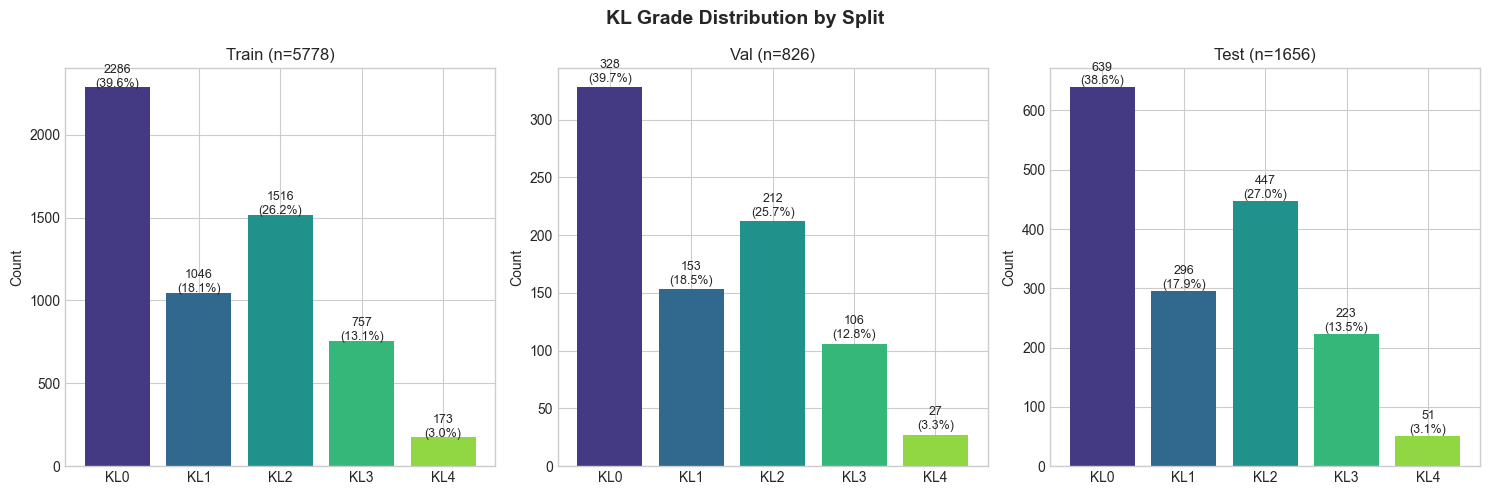

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, split in zip(axes, ['train', 'val', 'test']):
    counts = [stats[split][g] for g in range(5)]
    total = sum(counts)
    bars = ax.bar([f'KL{i}' for i in range(5)], counts,
                  color=sns.color_palette('viridis', 5))
    for bar, c in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                f'{c}\n({100*c/total:.1f}%)', ha='center', fontsize=9)
    ax.set_title(f'{split.capitalize()} (n={total})')
    ax.set_ylabel('Count')

fig.suptitle('KL Grade Distribution by Split', fontsize=14, weight='bold')
plt.tight_layout()
plt.savefig('../results/class_distribution.png', dpi=150)
plt.show()

## 3. Sample Images per KL Grade

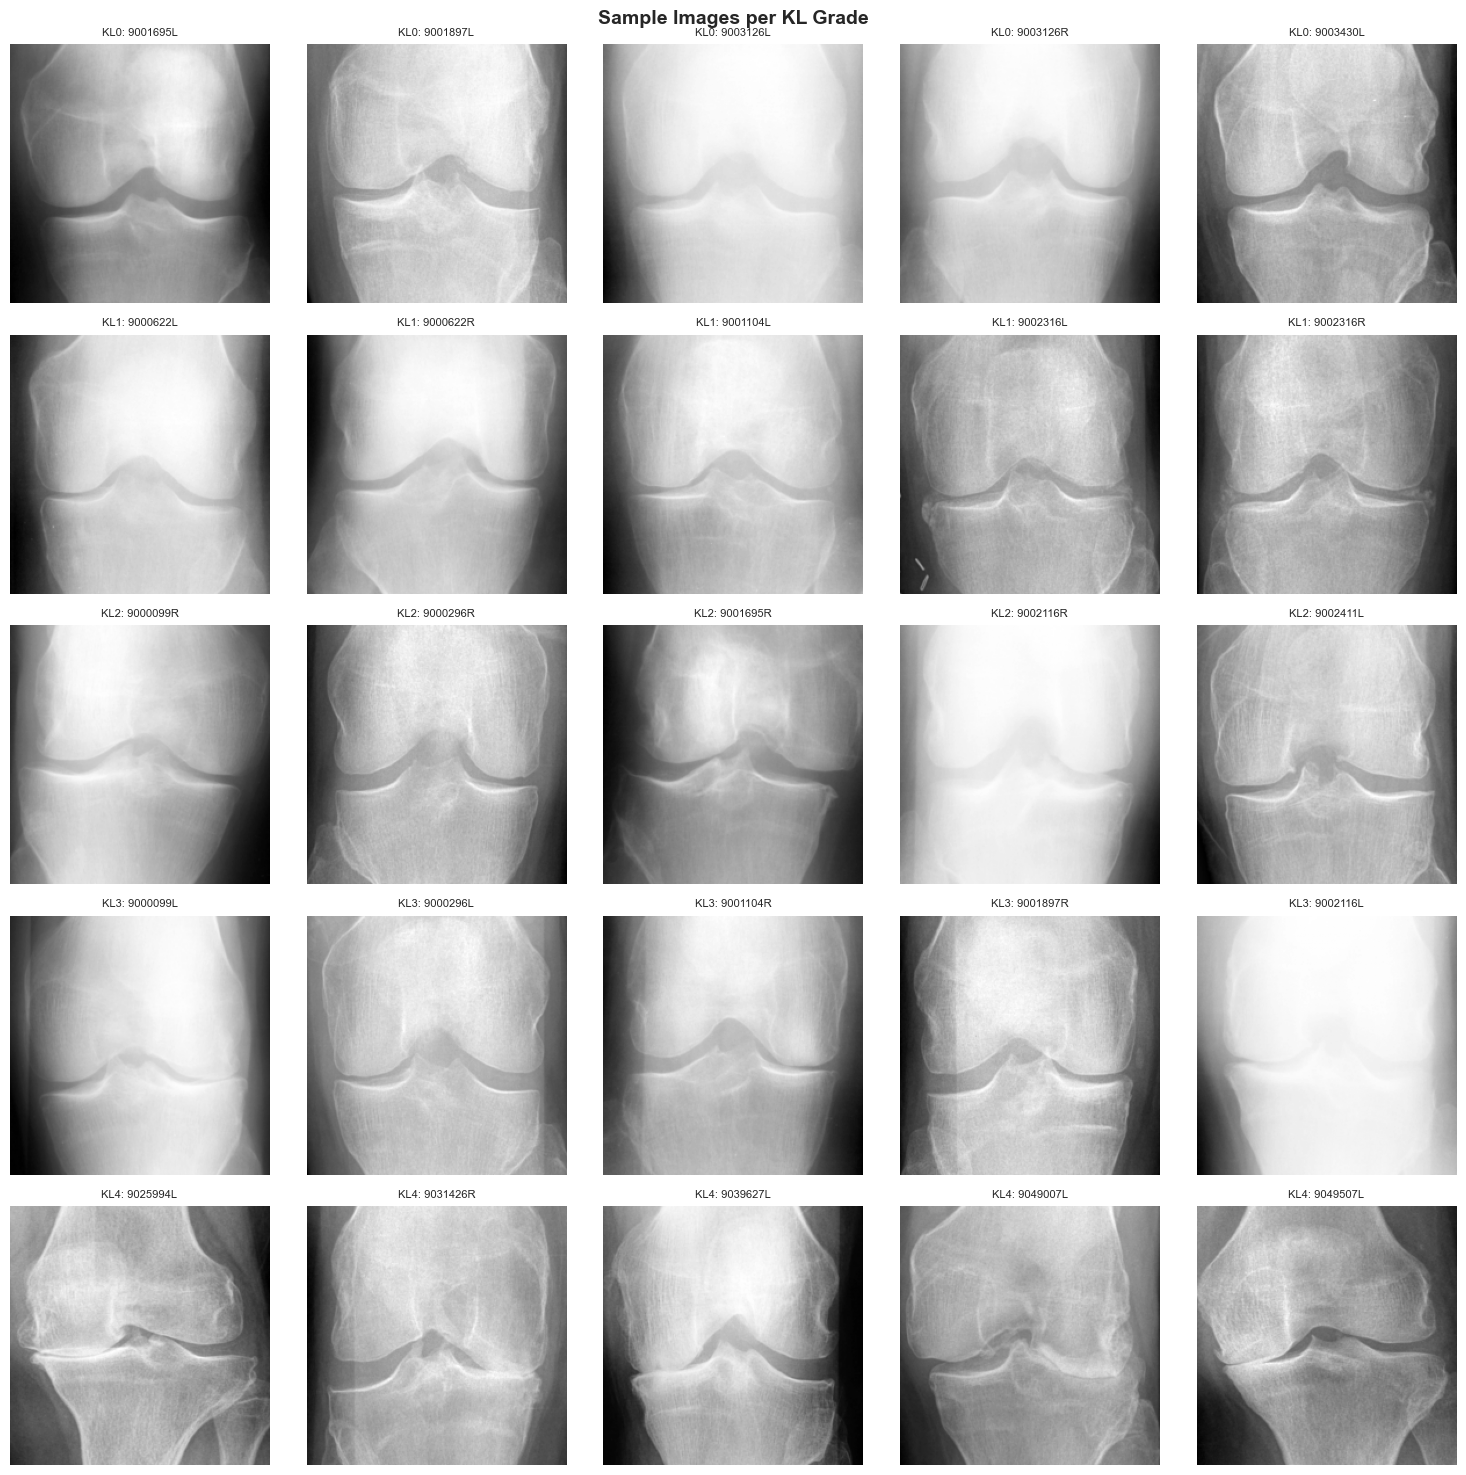

In [6]:
fig, axes = plt.subplots(5, 5, figsize=(15, 15))

for row, grade in enumerate(range(5)):
    grade_dir = DATA_ROOT / 'train' / str(grade)
    images = sorted(grade_dir.glob('*.png'))[:5]
    for col, img_path in enumerate(images):
        img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
        axes[row][col].imshow(img, cmap='gray')
        axes[row][col].set_title(f'KL{grade}: {img_path.stem}', fontsize=8)
        axes[row][col].axis('off')
    axes[row][0].set_ylabel(f'KL {grade}', fontsize=12, weight='bold')

fig.suptitle('Sample Images per KL Grade', fontsize=14, weight='bold')
plt.tight_layout()
plt.savefig('../results/sample_images.png', dpi=150)
plt.show()

## 4. Image Statistics per Grade

In [7]:
# Compute mean pixel intensity per grade
grade_stats = {}

for grade in range(5):
    grade_dir = DATA_ROOT / 'train' / str(grade)
    means, stds = [], []
    for img_path in list(grade_dir.glob('*.png'))[:200]:  # sample 200 per grade
        img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
        if img is not None:
            means.append(img.mean())
            stds.append(img.std())
    grade_stats[grade] = {'mean': np.mean(means), 'std': np.mean(stds),
                           'mean_std': np.std(means), 'min': min(means), 'max': max(means)}

df_img_stats = pd.DataFrame(grade_stats).T
df_img_stats.index = [f'KL{i}' for i in range(5)]
print('Image Intensity Statistics per Grade (sampled 200/grade):')
df_img_stats.round(2)

Image Intensity Statistics per Grade (sampled 200/grade):


,mean,std,mean_std,min,max
KL0,150.24,39.17,29.42,52.32,217.46
KL1,154.01,39.26,24.18,64.65,219.05
KL2,156.63,37.22,25.35,54.01,228.42
KL3,159.68,38.03,26.75,60.03,220.01
KL4,157.54,37.62,31.45,54.32,229.01


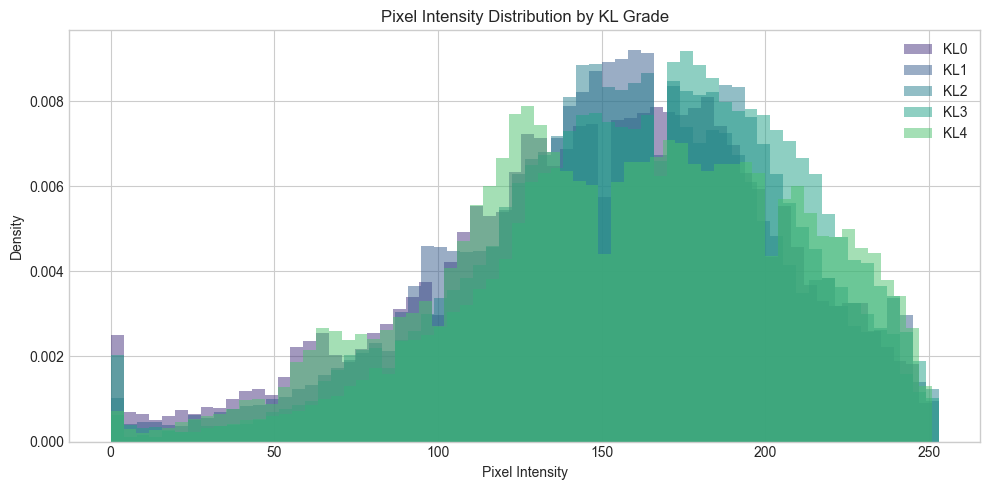

In [8]:
# Pixel intensity histograms per grade
fig, ax = plt.subplots(figsize=(10, 5))

for grade in range(5):
    grade_dir = DATA_ROOT / 'train' / str(grade)
    all_pixels = []
    for img_path in list(grade_dir.glob('*.png'))[:50]:
        img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
        if img is not None:
            all_pixels.extend(img.flatten()[::10].tolist())  # subsample
    ax.hist(all_pixels, bins=64, alpha=0.5, density=True, label=f'KL{grade}')

ax.set_xlabel('Pixel Intensity')
ax.set_ylabel('Density')
ax.set_title('Pixel Intensity Distribution by KL Grade')
ax.legend()
plt.tight_layout()
plt.savefig('../results/pixel_distributions.png', dpi=150)
plt.show()

## 5. Preprocessing Demo (CLAHE)

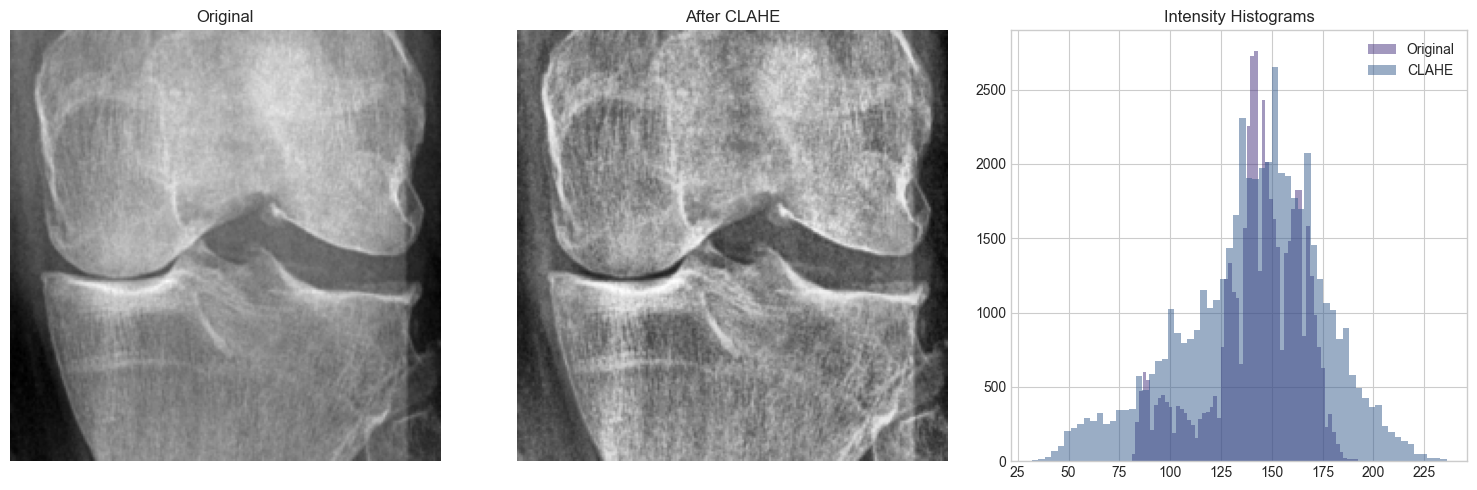

In [9]:
# Show before/after CLAHE
sample_img = cv2.imread(str(list((DATA_ROOT / 'train' / '3').glob('*.png'))[0]),
                        cv2.IMREAD_GRAYSCALE)

clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
enhanced = clahe.apply(sample_img)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(sample_img, cmap='gray')
axes[0].set_title('Original')
axes[1].imshow(enhanced, cmap='gray')
axes[1].set_title('After CLAHE')
axes[2].hist(sample_img.flatten(), bins=64, alpha=0.5, label='Original')
axes[2].hist(enhanced.flatten(), bins=64, alpha=0.5, label='CLAHE')
axes[2].legend()
axes[2].set_title('Intensity Histograms')

for ax in axes[:2]:
    ax.axis('off')
plt.tight_layout()
plt.savefig('../results/clahe_demo.png', dpi=150)
plt.show()

## 6. Laterality Check

In [10]:
# Check L/R distribution in filenames
left_count = 0
right_count = 0
unknown_count = 0

for grade in range(5):
    for img_path in (DATA_ROOT / 'train' / str(grade)).glob('*.png'):
        stem = img_path.stem
        if stem.endswith('L'):
            left_count += 1
        elif stem.endswith('R'):
            right_count += 1
        else:
            unknown_count += 1

print(f'Left knees: {left_count}')
print(f'Right knees: {right_count}')
print(f'Unknown: {unknown_count}')
print(f'Total: {left_count + right_count + unknown_count}')

Left knees: 2889
Right knees: 2889
Unknown: 0
Total: 5778
